## Pan Transformer inference

In [1]:
from model import Rec_Transformer
import torch
import numpy as np
import tifffile
import os
import matplotlib.pyplot as plt
from skimage.transform import resize
import kornia.geometry.transform as transform
from train import crop_borders

/home/ponoma/miniconda3/envs/LIT/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
os.environ["CUDA_DEVICE_ORDER"] = "PCI_BUS_ID" 
os.environ["CUDA_VISIBLE_DEVICES"] = '0,1,2'
gpu_number = 1

In [6]:
# dataset type
dataset = 'rml'
height = 300
width = 480

input_size = (height, width)
model = Rec_Transformer(input_size=input_size, rec_size=(height, width)) 

model_path = '/home/ponoma/workspace/Pan_Transformer/pan_0.5_rml_6_x4_downsize/best_model.pth'

if torch.cuda.is_available():
        device = torch.device("cuda")
        torch.cuda.set_device(gpu_number) 
else:
    device = torch.device("cpu")

model.to(device)

# load in the model
loaded_dict = torch.load(model_path, weights_only=True)
model_dict = model.state_dict()
loaded_dict = {k: v for k, v in loaded_dict.items() if k in model_dict}
model_dict.update(loaded_dict)
model.load_state_dict(model_dict) 

<All keys matched successfully>

Processing image 64...


(-0.5, 208.5, 208.5, -0.5)

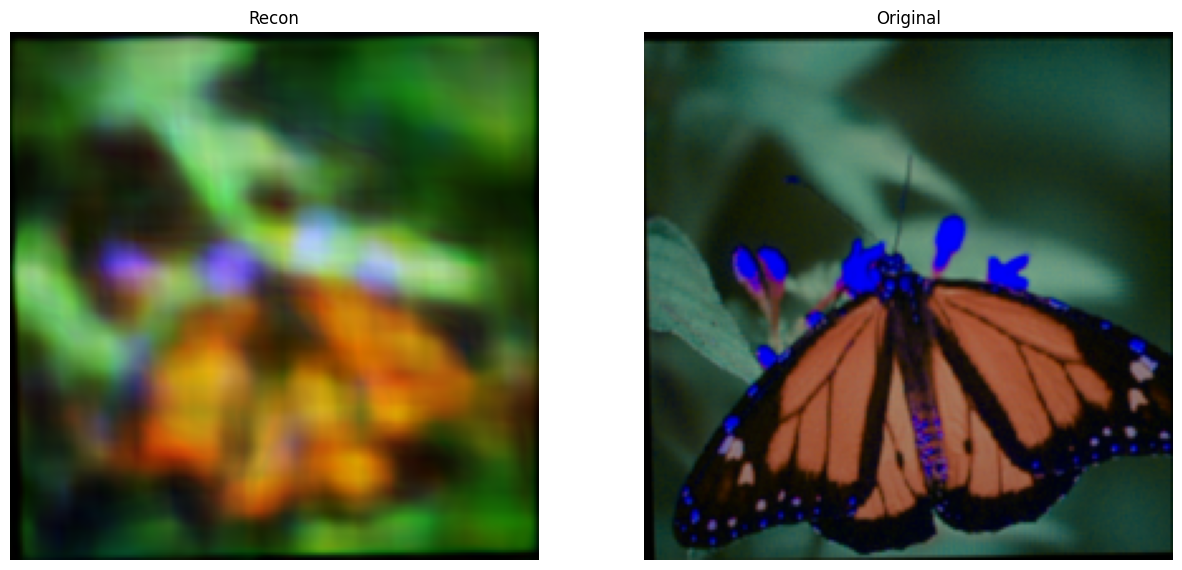

In [13]:
img_numbers = [64]#[1, 64, 93, 195, 912]
downsize_coeff = 4

homography_matrix = torch.load("/home/ponoma/workspace/Lensless_Image_Reconstruction/data/GT2RML_homography_x4_color_detached.npy").to(torch.float32).to(device)
homography_matrix = torch.inverse(homography_matrix)

model.eval()
for img_number in img_numbers:
    print(f"Processing image {img_number}...") 

    if dataset == "rml":
        image = tifffile.imread(f"/home/lakabuli/cosmos_drive/dataset100k/rml/img_{img_number}_cam_1.tiff")     # Already in RGB format
        target = tifffile.imread(f"/home/lakabuli/cosmos_drive/dataset100k/undistorted_images/undistorted_img_{img_number}_cam_2.tiff")

    image = (image/255).astype(np.float32)     # max of measurements is 255. Normalizing to range [0, 1]
    target = (target/255).astype(np.float32)

    height, width = image.shape[:2]
    image = resize(image, (height//downsize_coeff, width//downsize_coeff), anti_aliasing=True).astype(np.float32) 
    target = resize(target, (height//downsize_coeff, width//downsize_coeff), anti_aliasing=True).astype(np.float32)

    image = np.clip(image, 0,1)
    image = torch.from_numpy(image).permute(2, 0, 1).unsqueeze(0).to(device) # Shape: (1, 3, H, W)
    target = torch.from_numpy(target).permute(2, 0, 1).unsqueeze(0).to(device)

    reconstructed_channels = []
    with torch.no_grad():
        for c in range(3):
            single_channel_in = image[:, c, :, :].unsqueeze(1)

            #single_channel_in = (single_channel_in - single_channel_in.mean()) / single_channel_in.std()
            single_channel_out = model(single_channel_in.float())
            # single_channel_out, _ = crop_borders((single_channel_out, single_channel_out), dataset, downsize_coeff, batch=True)

            single_channel_out = torch.clamp(single_channel_out, 0, 1)
            reconstructed_channels.append(single_channel_out)

        # 5. Recombine Channels
        # Stack along dim 1 to get (1, 3, H, W)
        test_out_tensor = torch.cat(reconstructed_channels, dim=1)

        # RML -> GT transformation
        output = transform.warp_perspective(test_out_tensor.float(), homography_matrix, 
                                                dsize=(test_out_tensor.shape[2], test_out_tensor.shape[3])).squeeze()         # last two dimensions should be height and width
        output = torch.clamp(output, 0, 1)

    out_img = output.squeeze().cpu().permute(1, 2, 0).numpy()
    target_img = target.squeeze().cpu().permute(1, 2, 0).numpy()

    out_img_cropped = out_img[48:257, 124:333, :]
    target_cropped = target_img[48:257, 124:333, :]

fig, ax = plt.subplots(1, 2, figsize=(15,10))
ax[0].imshow(out_img_cropped)
ax[0].set_title('Recon')
ax[0].axis('off')

ax[1].imshow(target_cropped)
ax[1].set_title('Original')
ax[1].axis('off')